In [1]:
!pip install yfinance transformers torch scikit-learn pandas_market_calendars tqdm

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm

In [3]:
news = pd.read_csv("/Users/vaibhav/Documents/INLP/Project Trial1/dataset/raw_partner_headlines.csv")

In [4]:
# Rename columns properly
news = news.rename(columns={
    "stock": "Ticker",
    "headline": "News",
    "date": "Date"
})
news = news[['Date','News','Ticker']]
news['Date'] = pd.to_datetime(news['Date'])
news.head()

,Date,News,Ticker
0,2020-06-01,Agilent Technologies Announces Pricing of $5……...,A
1,2020-05-18,Agilent (A) Gears Up for Q2 Earnings: What's i...,A
2,2020-05-15,J.P. Morgan Asset Management Announces Liquida...,A
3,2020-05-15,"Pershing Square Capital Management, L.P. Buys ...",A
4,2020-05-12,Agilent Awards Trilogy Sciences with a Golden ...,A


In [5]:
top_100_tickers = (
    news['Ticker']
    .value_counts()
    .head(100)
    .index
    .tolist()
)

print(top_100_tickers[:10])
print("Total:", len(top_100_tickers))

['KR', 'GXC', 'PGJ', 'YINN', 'JPM', 'FXP', 'XPP', 'FCAU', 'CHN', 'JWN']
Total: 100


In [6]:
news_top100 = news[news['Ticker'].isin(top_100_tickers)].copy()

print(news_top100.shape)

(219825, 3)


In [7]:
import yfinance as yf
import datetime

today = datetime.date.today()

all_prices = []
working_tickers = []

for ticker in top_100_tickers:
    try:
        df = yf.download(
            ticker,
            start="2009-01-01",
            end=today,
            progress=False
        )
        
        if not df.empty:

            # 🔥 ADD THIS BLOCK (THIS FIXES THE PROBLEM)
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)

            df = df.reset_index()
            df['Ticker'] = ticker

            all_prices.append(df)
            working_tickers.append(ticker)
        else:
            print("No data:", ticker)
            
    except Exception as e:
        print("Failed:", ticker)

price_df = pd.concat(all_prices, axis=0, ignore_index=True)

print("Final working tickers:", len(working_tickers))

$FCAU: possibly delisted; no timezone found

1 Failed download:
['FCAU']: possibly delisted; no timezone found


No data: FCAU


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: CHN"}}}
$CHN: possibly delisted; no timezone found

1 Failed download:
['CHN']: possibly delisted; no timezone found


No data: CHN


$JWN: possibly delisted; no timezone found

1 Failed download:
['JWN']: possibly delisted; no timezone found


...

No data: TIF


$RAD: possibly delisted; no timezone found

1 Failed download:
['RAD']: possibly delisted; no timezone found


No data: RAD


$ANTM: possibly delisted; no timezone found

1 Failed download:
['ANTM']: possibly delisted; no timezone found


No data: ANTM
Final working tickers: 83


In [8]:
import requests
import time

API_KEY = "d6ijdf1r01qm7dc7noh0d6ijdf1r01qm7dc7nohg"

def fetch_company_news(ticker, start_date, end_date):
    url = f"https://finnhub.io/api/v1/company-news?symbol={ticker}&from={start_date}&to={end_date}&token={API_KEY}"
    
    response = requests.get(url)
    
    if response.status_code != 200:
        return pd.DataFrame()
    
    data = response.json()
    
    if len(data) == 0:
        return pd.DataFrame()
    
    df = pd.DataFrame(data)
    df = df[['datetime','headline']]
    df['datetime'] = pd.to_datetime(df['datetime'], unit='s')
    df['Ticker'] = ticker
    df.columns = ['Date','News','Ticker']
    
    return df

In [9]:
new_news = []

for ticker in working_tickers:
    print("Fetching:", ticker)
    
    df_news = fetch_company_news(
        ticker,
        "2021-01-01",
        str(today)
    )
    
    new_news.append(df_news)
    
    time.sleep(1)  # avoid rate limit

new_news_df = pd.concat(new_news, ignore_index=True)

Fetching: KR
Fetching: GXC
Fetching: PGJ
Fetching: YINN
Fetching: JPM
Fetching: FXP
Fetching: XPP
Fetching: ERO
Fetching: RSP
Fetching: OXY
Fetching: BLK
Fetching: VGK
Fetching: MDT
Fetching: UGAZ
Fetching: KEY
Fetching: AVGO
Fetching: TJX
Fetching: VNQ
Fetching: INTC
Fetching: DGAZ
Fetching: DOW
Fetching: CI
Fetching: WDC
Fetching: CSX
Fetching: VWO
Fetching: PBR
Fetching: SLV
Fetching: DUK
Fetching: ALK
Fetching: XLU
Fetching: FCA
Fetching: DZZ
Fetching: PANW
Fetching: STZ
Fetching: D
Fetching: HYG
Fetching: TRV
Fetching: JD
Fetching: DRR
Fetching: TXN
Fetching: EWJ
Fetching: SLB
Fetching: XLY
Fetching: FCX
Fetching: REGN
Fetching: ULTA
Fetching: GRPN
Fetching: LEN
Fetching: TSN
Fetching: OHI
Fetching: KSS
Fetching: GILD
Fetching: AEO
Fetching: EPV
Fetching: BUD
Fetching: KMB
Fetching: AXP
Fetching: AGG
Fetching: JNK
Fetching: LUV
Fetching: GME
Fetching: ENB
Fetching: SIRI
Fetching: ABX
Fetching: GOLD
Fetching: EW
Fetching: VTR
Fetching: BAX
Fetching: HD
Fetching: GDXJ
Fetching: TWX


In [10]:
combined_news = pd.concat([news_top100, new_news_df])
combined_news.drop_duplicates(subset=['News'], inplace=True)

combined_news.reset_index(drop=True, inplace=True)
combined_news.shape

(162408, 3)

In [11]:
!pip install transformers torch tqdm

In [12]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import numpy as np
from tqdm import tqdm

tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [13]:
def get_sentiment_batch(texts, batch_size=32):
    results = []
    
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True, return_tensors="pt").to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
        
        probs = torch.softmax(outputs.logits, dim=1)
        results.extend(probs.cpu().numpy())
    
    return np.array(results)

probs = get_sentiment_batch(combined_news['News'].tolist())

combined_news[['neg','neu','pos']] = probs
combined_news['sentiment_score'] = combined_news['pos'] - combined_news['neg']

100%|███████████████████████████████████████| 5076/5076 [21:41<00:00,  3.90it/s]


In [14]:
price_df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker'], dtype='object', name='Price')

In [15]:
daily_sentiment = (
    combined_news
    .groupby(['Ticker','Date'])['sentiment_score']
    .mean()
    .reset_index()
)

In [16]:
if isinstance(price_df.columns, pd.MultiIndex):
    price_df.columns = price_df.columns.get_level_values(0)
price_df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker'], dtype='object', name='Price')

In [17]:
test = yf.download(working_tickers[0], start="2009-01-01", progress=False)
print(test.head())
print(test.columns)

Price          Close      High       Low      Open    Volume
Ticker            KR        KR        KR        KR        KR
Date                                                        
2009-01-02  9.601729  9.648761  9.453398  9.583640  10098400
2009-01-05  9.648761  9.688557  9.493194  9.576404   9812000
2009-01-06  9.174824  9.746441  9.135027  9.677702  21260400
2009-01-07  9.258038  9.428076  9.138649  9.138649  14156800
2009-01-08  9.091616  9.294215  9.008406  9.243565  18790000
MultiIndex([( 'Close', 'KR'),
            (  'High', 'KR'),
            (   'Low', 'KR'),
            (  'Open', 'KR'),
            ('Volume', 'KR')],
           names=['Price', 'Ticker'])


In [18]:
price_df['Date'] = pd.to_datetime(price_df['Date'])

final_df = pd.merge(
    price_df,
    daily_sentiment,
    on=['Ticker','Date'],
    how='left'
)

final_df['sentiment_score'] = final_df['sentiment_score'].fillna(0)

In [19]:
final_df['Return'] = final_df.groupby('Ticker')['Close'].pct_change()

In [20]:
from sklearn.preprocessing import MinMaxScaler

feature_cols = ['Open','High','Low','Close','Volume','sentiment_score']

scaler = MinMaxScaler()

final_df[feature_cols] = scaler.fit_transform(final_df[feature_cols])

In [21]:
def create_sequences(df, lookback=60):
    X, y = [], []
    
    for ticker in df['Ticker'].unique():
        temp = df[df['Ticker'] == ticker].sort_values('Date')
        data = temp[['Open','High','Low','Close','Volume','sentiment_score']].values
        target = temp['Return'].values
        
        for i in range(lookback, len(data)-1):
            X.append(data[i-lookback:i])
            y.append(target[i+1])
    
    return np.array(X), np.array(y)

X, y = create_sequences(final_df)

In [22]:
split = int(len(X)*0.9)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [23]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── 1. Convert to tensors ────────────────────────────────────────────
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=256, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)



Using device: cpu


In [24]:

# ── 2. LSTM Model ────────────────────────────────────────────────────
class StockLSTM(nn.Module):
    def __init__(self, input_size=6, hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]   # take last timestep
        return self.fc(out)

model = StockLSTM().to(device)
print(model)

StockLSTM(
  (lstm): LSTM(6, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [25]:

# ── 3. Loss & Optimizer ──────────────────────────────────────────────
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

In [26]:
from tqdm import tqdm

# ── 4. Training Loop ─────────────────────────────────────────────────
EPOCHS = 30
train_losses = []
prev_lr = optimizer.param_groups[0]['lr']

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0

    loop = tqdm(train_loader, desc=f"Epoch {epoch:3d}/{EPOCHS}", leave=True)

    for X_batch, y_batch in loop:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item() * len(X_batch)

        # Live loss update in the bar
        loop.set_postfix(batch_mse=f"{loss.item():.6f}")

    epoch_loss /= len(train_dataset)
    train_losses.append(epoch_loss)
    scheduler.step(epoch_loss)

    # Update bar with final epoch loss
    loop.set_postfix(epoch_mse=f"{epoch_loss:.6f}")

    curr_lr = optimizer.param_groups[0]['lr']
    if curr_lr != prev_lr:
        print(f"  → LR reduced to {curr_lr:.2e}")
        prev_lr = curr_lr
print("\nTraining complete!")

Epoch   7/30: 100%|█████| 1149/1149 [01:51<00:00, 10.27it/s, batch_mse=0.000532]


  → LR reduced to 5.00e-04


Epoch  12/30: 100%|█████| 1149/1149 [01:52<00:00, 10.19it/s, batch_mse=0.000459]


  → LR reduced to 2.50e-04


Epoch  17/30: 100%|█████| 1149/1149 [01:51<00:00, 10.29it/s, batch_mse=0.003221]


...

  → LR reduced to 6.25e-05


Epoch  27/30: 100%|█████| 1149/1149 [02:00<00:00,  9.55it/s, batch_mse=0.000402]


  → LR reduced to 3.13e-05


Epoch  30/30: 100%|█████| 1149/1149 [01:54<00:00, 10.02it/s, batch_mse=0.000359]


Training complete!


In [27]:
# ── 5. Evaluation on Test Set ────────────────────────────────────────
model.eval()
with torch.no_grad():
    y_pred = model(X_test_t.to(device)).cpu().numpy().flatten()
    y_true = y_test_t.numpy().flatten()

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mse  = mean_squared_error(y_true, y_pred)
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)

print(f"\nTest Results:")
print(f"  RMSE : {rmse:.6f}")
print(f"  MAE  : {mae:.6f}")
print(f"  MSE  : {mse:.6f}")



Test Results:
  RMSE : 0.022218
  MAE  : 0.012864
  MSE  : 0.000494


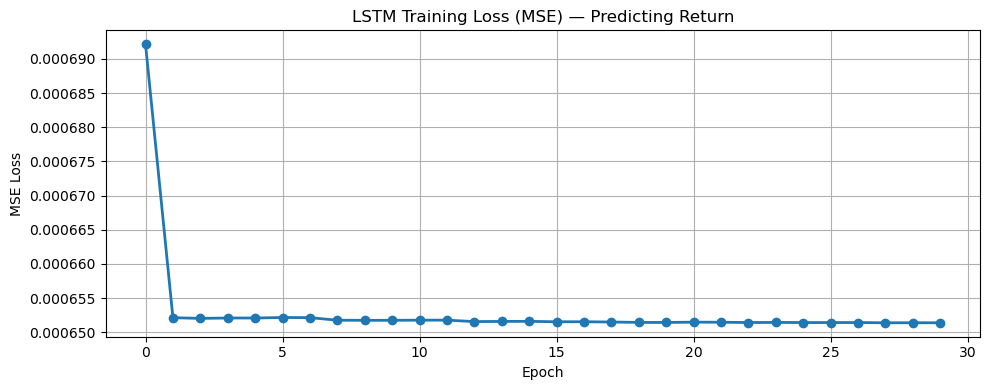

In [28]:
# ── 6. Plot Training Loss ────────────────────────────────────────────
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(train_losses, marker='o', linewidth=2)
plt.title("LSTM Training Loss (MSE) — Predicting Return")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

In [29]:
# ── 7. Save model ────────────────────────────────────────────────────
torch.save(model.state_dict(), "lstm_stock_model.pt")
print("Model saved to lstm_stock_model.pt")

Model saved to lstm_stock_model.pt


   DIRECTION PREDICTION METRICS
  Accuracy  : 0.5233  (52.33%)
  Precision : 0.5233
  Recall    : 1.0000
  F1 Score  : 0.6871

Note: Random guessing = ~50% accuracy
      Your model     = 52.33% accuracy

Detailed Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.00      0.00      0.00     15569
      Up (1)       0.52      1.00      0.69     17094

    accuracy                           0.52     32663
   macro avg       0.26      0.50      0.34     32663
weighted avg       0.27      0.52      0.36     32663



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


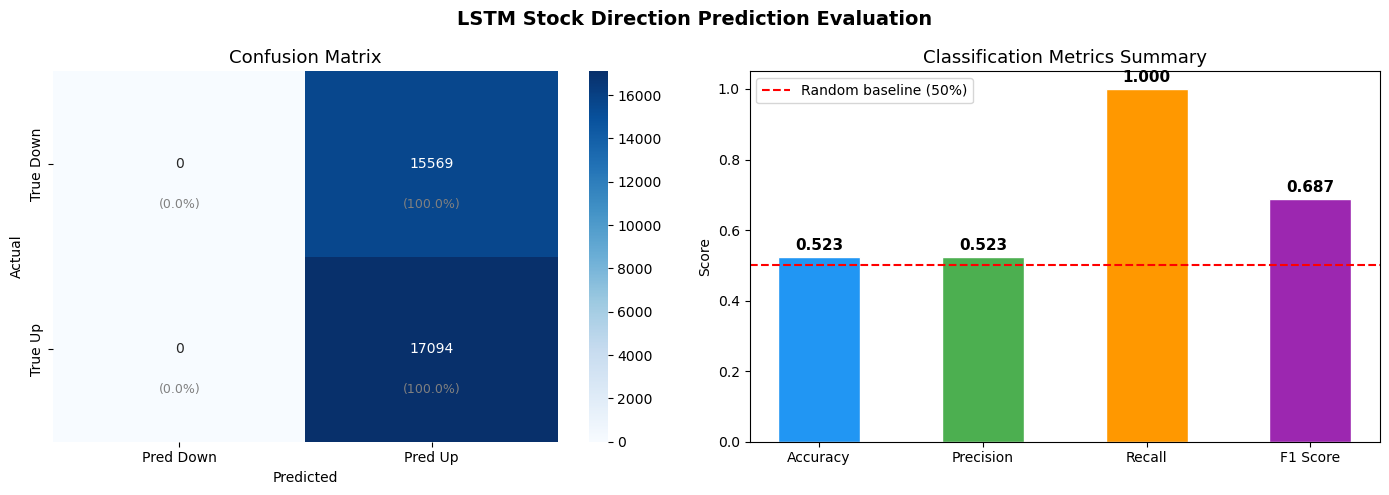

In [30]:
# ── Classification Metrics (Direction Prediction) ───────────────────
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

# Convert returns to binary direction: 1 = Up, 0 = Down
y_true_dir = (y_true > 0).astype(int)
y_pred_dir = (y_pred > 0).astype(int)

# ── Core Metrics ─────────────────────────────────────────────────────
accuracy  = accuracy_score(y_true_dir, y_pred_dir)
precision = precision_score(y_true_dir, y_pred_dir, zero_division=0)
recall    = recall_score(y_true_dir, y_pred_dir, zero_division=0)
f1        = f1_score(y_true_dir, y_pred_dir, zero_division=0)

print("=" * 45)
print("   DIRECTION PREDICTION METRICS")
print("=" * 45)
print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print("=" * 45)
print()
print("Note: Random guessing = ~50% accuracy")
print(f"      Your model     = {accuracy*100:.2f}% accuracy")
print()

# ── Full Classification Report ────────────────────────────────────────
print("Detailed Classification Report:")
print(classification_report(y_true_dir, y_pred_dir, target_names=["Down (0)", "Up (1)"]))

# ── Confusion Matrix ──────────────────────────────────────────────────
cm = confusion_matrix(y_true_dir, y_pred_dir)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=["Pred Down", "Pred Up"],
    yticklabels=["True Down", "True Up"],
    ax=axes[0]
)
axes[0].set_title("Confusion Matrix", fontsize=13)
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
for i in range(2):
    for j in range(2):
        axes[0].text(j + 0.5, i + 0.72, f"({cm_pct[i,j]:.1f}%)",
                     ha='center', va='center', fontsize=9, color='gray')

# ── Metrics Bar Chart ─────────────────────────────────────────────────
metrics_names  = ["Accuracy", "Precision", "Recall", "F1 Score"]
metrics_values = [accuracy, precision, recall, f1]
colors = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"]

bars = axes[1].bar(metrics_names, metrics_values, color=colors, width=0.5, edgecolor='white')
axes[1].axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Random baseline (50%)')
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Classification Metrics Summary", fontsize=13)
axes[1].set_ylabel("Score")
axes[1].legend()

for bar, val in zip(bars, metrics_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{val:.3f}", ha='center', fontsize=11, fontweight='bold')

plt.suptitle("LSTM Stock Direction Prediction Evaluation", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()